# 四个 baseline 与 DST k=10 的五折 Wilcoxon 分析

## tl;dr

- 在统一的 8,409 张测试图像、862 名患者上，五模型集成的患者级 AUROC 排名为：MIL 0.872、Mammo-FM 0.862、Mammo-CLIP 0.828、DST k=10 0.810、GLAM 0.672。
- 名义 fold 配对的双侧精确 Wilcoxon 检验中，所有比较的原始 p 值均不小于 0.0625；Holm 校正后均不显著。
- DST k=10 对 GLAM 的五折 AUROC 在图像级和患者级均为 5/5 胜；对 MIL 的患者级 AUROC 为 0/5 胜。方向稳定，但只有五对观测时统计功效不足。
- 各系统训练/验证 fold 的患者划分并不一致，因此 fold 编号配对只是探索性分析，不能作为严格匹配重采样检验。

## Context & Methods

### Key Assumptions

- 正类为 `cancer=1`；所有 score 均按癌症概率方向解释。
- 图像级分析限定为五个系统共同拥有的 8,409 张测试图像（66 个阳性）；患者级标签取患者内最大值，患者得分取图像得分均值，共 862 名患者（19 个阳性）。
- 五模型集成分数为同一图像五个 fold 模型分数的均值。
- Wilcoxon 使用同名 fold 编号构成 5 对观测，双侧、精确法。主检验为图像级与患者级 AUROC 共 8 个比较，并用 Holm 法校正。
- 固定阈值 0.5 的 balanced accuracy、sensitivity、specificity 作为次要校准敏感性分析，单独对 24 个比较做 Holm 校正。

注意：当 n=5 且差值均非零时，双侧精确 Wilcoxon 的最小可达 p 值为 0.0625，因此这项检验本身不可能在 0.05 水平达到显著。

## Data

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

from analyze import run_analysis

output_dir = Path.cwd()
outputs = run_analysis()
source_validation = outputs["source_validation"]
label_validation = outputs["label_validation"]
fold_metrics = outputs["fold_metrics"]
ensemble_metrics = outputs["ensemble_metrics"]
fold_alignment = outputs["fold_alignment"]
wilcoxon_auc = outputs["wilcoxon_auc"]
wilcoxon_secondary = outputs["wilcoxon_secondary"]

source_validation.groupby("model").agg(
    folds=("fold", "nunique"),
    common_test_rows=("common_test_rows", "min"),
    common_test_patients=("common_test_patients", "min"),
    duplicate_keys=("duplicate_patient_image_keys", "sum"),
    score_nulls=("score_nulls", "sum"),
)

,folds,common_test_rows,common_test_patients,duplicate_keys,score_nulls
model,,,,,
DST k=10,5,8409,862,0,0
GLAM,5,8409,862,0,0
MIL,5,8409,862,0,0
Mammo-CLIP,5,8409,862,0,0
Mammo-FM,5,8409,862,0,0


In [2]:
label_validation

,model,common_keys,label_mismatches_vs_mammo_fm
0,Mammo-FM,8409,0
1,Mammo-CLIP,8409,0
2,MIL,8409,0
3,GLAM,8409,0
4,DST k=10,8409,0


## Results

In [3]:
ensemble_metrics.loc[:, [
    "model", "grain", "n", "positives", "auc", "average_precision",
    "bacc_0p5", "sensitivity_0p5", "specificity_0p5"
]].sort_values(["grain", "auc"], ascending=[True, False]).round(4)

,model,grain,n,positives,auc,average_precision,bacc_0p5,sensitivity_0p5,specificity_0p5
0,Mammo-FM,image,8409,66,0.8552,0.0452,0.7366,0.6061,0.8671
2,Mammo-CLIP,image,8409,66,0.8272,0.0511,0.7265,0.5606,0.8925
4,MIL,image,8409,66,0.8255,0.0603,0.7028,0.5303,0.8753
8,DST k=10,image,8409,66,0.7659,0.0343,0.6750,0.4848,0.8652
6,GLAM,image,8409,66,0.6994,0.0307,0.6429,0.4091,0.8767
5,MIL,patient,862,19,0.8718,0.1303,0.6743,0.4211,0.9276
1,Mammo-FM,patient,862,19,0.8623,0.1113,0.7205,0.5263,0.9146
3,Mammo-CLIP,patient,862,19,0.8279,0.1066,0.7270,0.5263,0.9276
9,DST k=10,patient,862,19,0.8105,0.1215,0.7042,0.4737,0.9348
7,GLAM,patient,862,19,0.6720,0.1017,0.5731,0.3158,0.8304


### 集成结果

患者级集成 AUROC 显示，DST k=10 明显高于 GLAM，但低于 MIL、Mammo-FM 和 Mammo-CLIP。图像级 AUROC 的相对方向相似。固定 0.5 阈值的分类指标还受到各模型校准差异影响，因此不应替代 AUROC 作为主要排序依据。

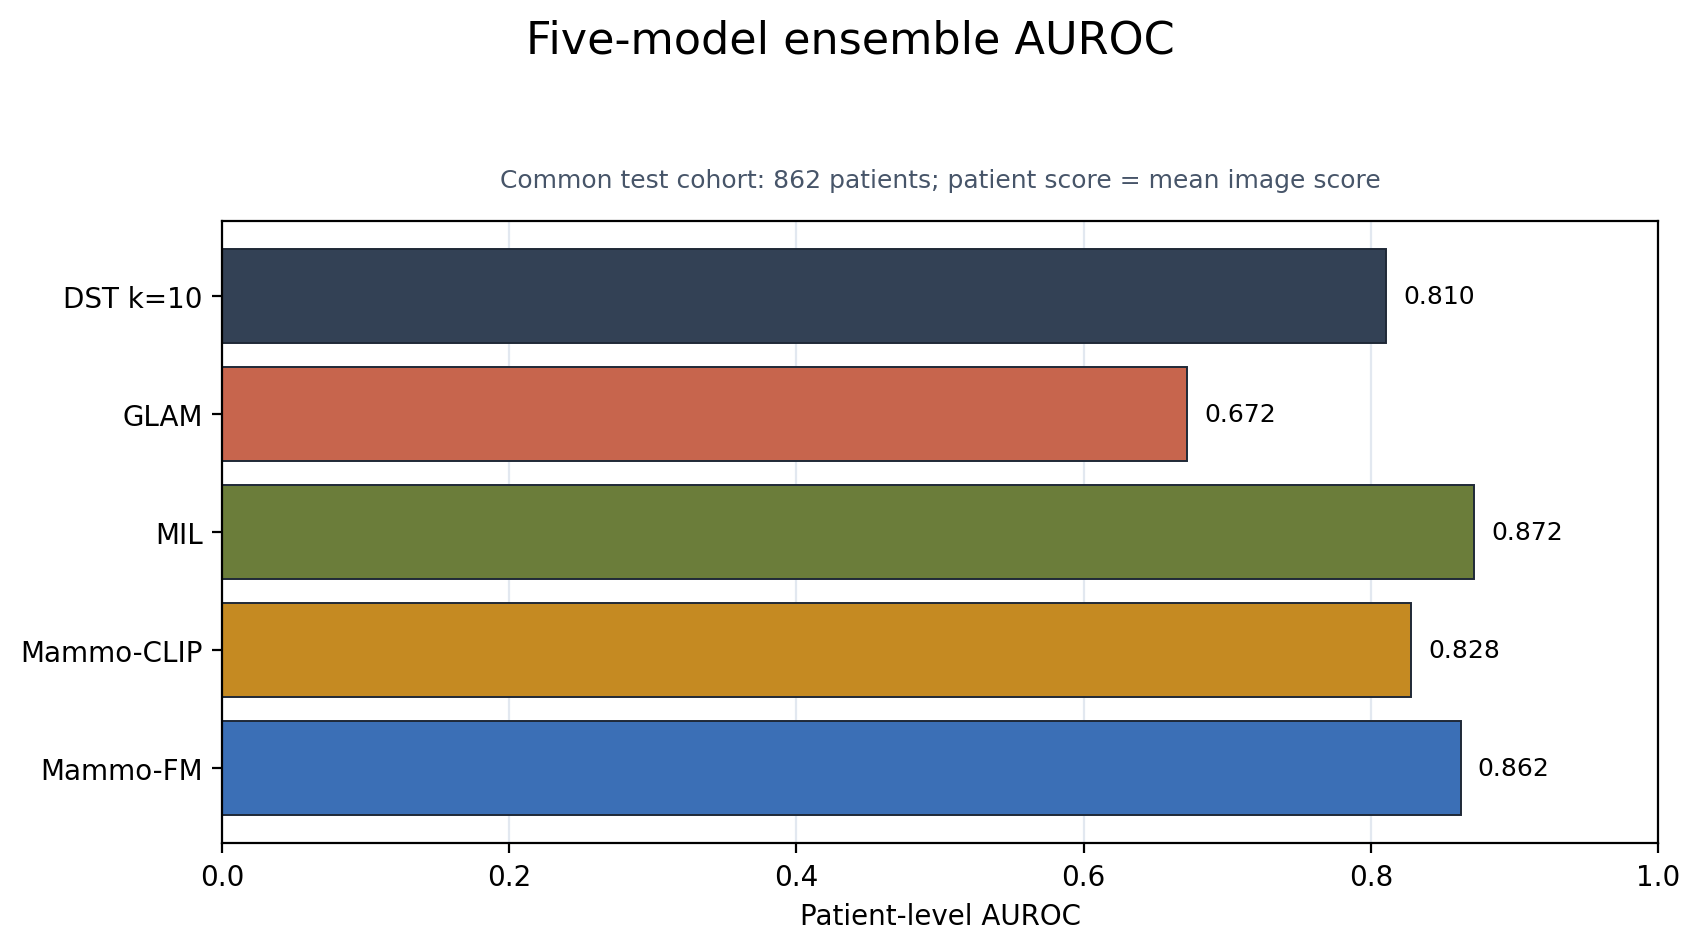

In [4]:
display(Image(filename=str(output_dir / 'ensemble_patient_auc.png')))

### 五折分布

每个点是一套 fold 模型在共同测试集上的患者级 AUROC，横线为五折均值。该图展示重复训练模型之间的离散程度，不表示这些 fold 在系统间共享了相同验证患者。

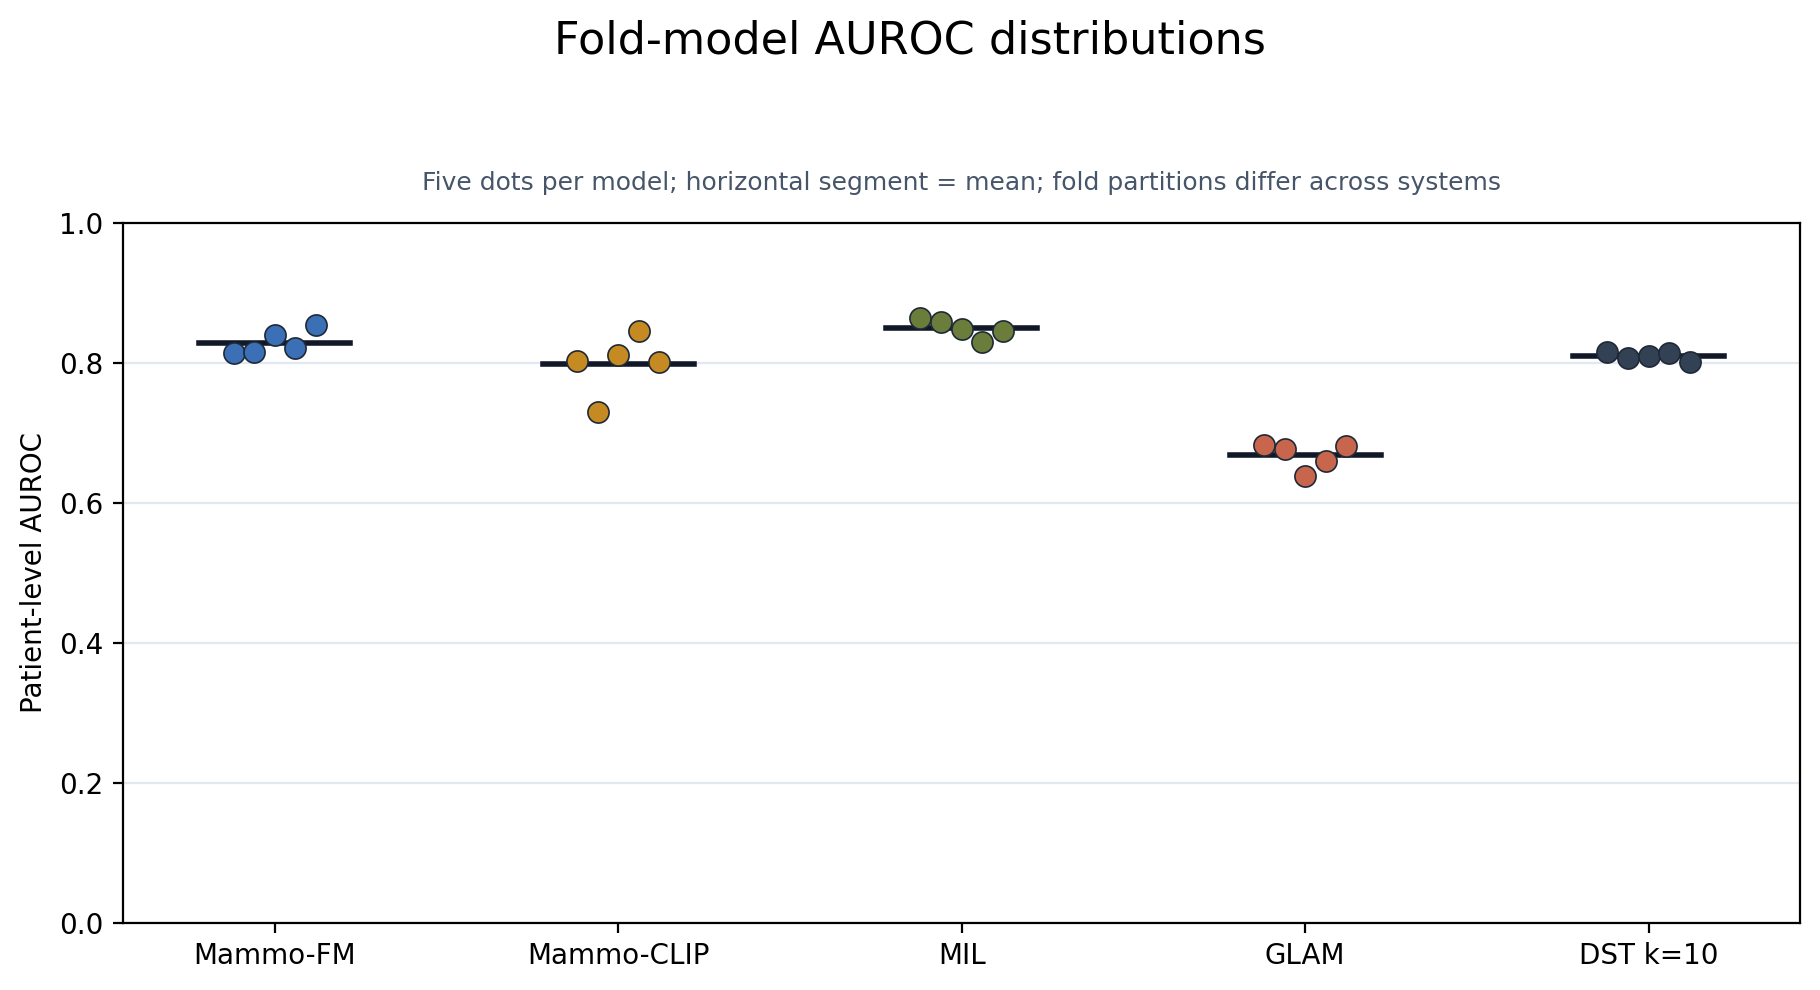

In [5]:
display(Image(filename=str(output_dir / 'fold_patient_auc.png')))

## Wilcoxon results

In [6]:
wilcoxon_auc.loc[:, [
    "grain", "baseline", "dst_mean", "baseline_mean",
    "mean_delta_dst_minus_baseline", "wins_dst", "losses_dst",
    "wilcoxon_w", "p_raw", "p_holm", "rank_biserial_dst_minus_baseline"
]].round(4)

,grain,baseline,dst_mean,baseline_mean,mean_delta_dst_minus_baseline,wins_dst,losses_dst,wilcoxon_w,p_raw,p_holm,rank_biserial_dst_minus_baseline
0,image,GLAM,0.7642,0.6877,0.0765,5,0,0.0,0.0625,0.500,1.0000
1,image,Mammo-FM,0.7642,0.8098,-0.0456,0,5,0.0,0.0625,0.500,-1.0000
2,image,MIL,0.7642,0.7941,-0.0299,1,4,1.0,0.1250,0.500,-0.8667
3,image,Mammo-CLIP,0.7642,0.7842,-0.0200,2,3,3.0,0.3125,0.625,-0.6000
4,patient,GLAM,0.8097,0.6681,0.1416,5,0,0.0,0.0625,0.500,1.0000
5,patient,MIL,0.8097,0.8497,-0.0400,0,5,0.0,0.0625,0.500,-1.0000
6,patient,Mammo-FM,0.8097,0.8295,-0.0198,1,4,1.0,0.1250,0.500,-0.8667
7,patient,Mammo-CLIP,0.8097,0.7983,0.0114,2,3,7.0,1.0000,1.000,0.0667


Wilcoxon 的方向性结果很清楚：DST k=10 相对 GLAM 为稳定改善；相对 MIL，尤其患者级，则为稳定下降。尽管如此，五对观测无法让双侧精确检验达到 p<0.05，Holm 校正后也没有显著比较。

In [7]:
wilcoxon_secondary.loc[:, [
    "grain", "metric", "baseline", "mean_delta_dst_minus_baseline",
    "wins_dst", "losses_dst", "p_raw", "p_holm"
]].round(4)

,grain,metric,baseline,mean_delta_dst_minus_baseline,wins_dst,losses_dst,p_raw,p_holm
0,image,bacc_0p5,GLAM,0.1112,5,0,0.0625,1.0
1,image,bacc_0p5,Mammo-FM,-0.0308,1,4,0.1250,1.0
2,image,bacc_0p5,MIL,-0.0178,1,4,0.4375,1.0
3,image,bacc_0p5,Mammo-CLIP,0.0003,1,4,0.6250,1.0
4,image,sensitivity_0p5,Mammo-FM,-0.1182,1,4,0.1250,1.0
5,image,sensitivity_0p5,MIL,-0.0788,1,4,0.4375,1.0
6,image,sensitivity_0p5,Mammo-CLIP,-0.0727,1,4,0.4375,1.0
7,image,sensitivity_0p5,GLAM,-0.0576,3,2,0.8125,1.0
8,image,specificity_0p5,Mammo-FM,0.0567,4,1,0.1875,1.0
9,image,specificity_0p5,Mammo-CLIP,0.0734,4,1,0.4375,1.0


## Validation and limitations

In [8]:
fold_alignment.groupby("baseline").agg(
    same_index_jaccard_mean=("jaccard", lambda s: s.iloc[[0, 6, 12, 18, 24]].mean()),
    all_pair_jaccard_min=("jaccard", "min"),
    all_pair_jaccard_max=("jaccard", "max"),
).round(4)

,same_index_jaccard_mean,all_pair_jaccard_min,all_pair_jaccard_max
baseline,,,
GLAM,0.1074,0.0827,0.1260
MIL,0.1110,0.0967,0.1273
Mammo-CLIP,0.1108,0.0923,0.1334
Mammo-FM,0.1193,0.0932,0.1269


- 五个系统的测试样本和标签一致，但 Mammo-FM 原文件额外包含 24 张测试图像；为保证公平，所有计算都取五个系统的共同 8,409 张图像。
- 训练/验证 fold 的患者分配不一致，故 fold 配对 Wilcoxon 只能作为方向性、探索性结果。
- 患者级阳性仅 19 人，患者 AUROC 对少量阳性排序变化较敏感。
- 固定阈值 0.5 的结果同时反映判别力与概率校准，不适合直接解释为某个架构必然更优。
- 若要做正式显著性结论，应在完全相同的外层折上重训全部系统，或在共同测试样本上使用患者级 bootstrap / AUROC 的配对比较。

## Takeaways

1. **描述性排序：**MIL 和 Mammo-FM 是这批本地结果里最强的患者级 baseline；DST k=10 位于 Mammo-CLIP 与 GLAM 之间。
2. **DST 的稳定优势只出现在 GLAM 对比：**图像级和患者级均为五折全胜，但 n=5 的精确 Wilcoxon 仍只能达到 p=0.0625。
3. **不要把“不显著”理解为“没有差异”：**这里主要是样本量和 fold 不匹配限制，而不是证据证明模型等价。
4. **正式论文建议：**统一五折划分后重算，并将患者级配对 bootstrap 或 DeLong/置换检验作为主要不确定性分析。